In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np

## Arnold on Classical Image

In [3]:
def arnold(image, iterations, a=1, b=1):
    height, width = image.shape
    mapping = {}
    
    for i in range(iterations):
        output = np.zeros((height, width), dtype=int)
        
        for x in range(height):
            for y in range(width):
                intensity = image[x,y]
                x_1 = (x+a*y)%height
                y_1 = (a*x+(a*b+1)*y)%width
                output[x_1,y_1] = intensity
                mapping[(x,y)]=(x_1,y_1)

    image = output.copy()
    return image

In [4]:
def undo_arnold(image,iterations,a=1,b=1):
    height, width = image.shape

    for i in range(iterations):
        output = np.zeros((height, width), dtype=int)
        
        for x in range(height):
            for y in range(width):
                intensity = image[x,y]
                x_1 = ((a*b+1)*x-a*y)%height
                y_1 = (-b*x+y)%width
                output[x_1,y_1] = intensity

    image = output.copy()
    return image

In [5]:
np.random.seed(42)
image = np.random.randint(0, 256, (4, 4), dtype=np.uint8)
image

array([[102, 220, 225,  95],
       [179,  61, 234, 203],
       [ 92,   3,  98, 243],
       [ 14, 149, 245,  46]], dtype=uint8)

In [6]:
img=arnold(image,1)
img

array([[102, 149,  98, 203],
       [243, 179, 220, 245],
       [225,  46,  92,  61],
       [  3, 234,  95,  14]])

In [7]:
img1 = arnold(image,49)
img1

array([[102, 149,  98, 203],
       [243, 179, 220, 245],
       [225,  46,  92,  61],
       [  3, 234,  95,  14]])

In [8]:
undo_arnold(img1,49)

array([[102, 220, 225,  95],
       [179,  61, 234, 203],
       [ 92,   3,  98, 243],
       [ 14, 149, 245,  46]])

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

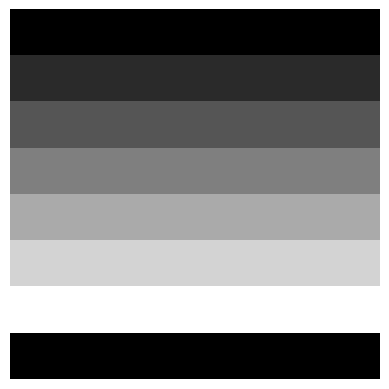

In [9]:
import numpy as np
import matplotlib.pyplot as plt

height, width = 32,32
bands = 7
band_height = height // bands

image = np.zeros((height, width), dtype=np.uint8)

for i in range(bands):
    intensity = int(255 * i / (bands - 1))
    image[i * band_height:(i + 1) * band_height, :] = intensity

plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

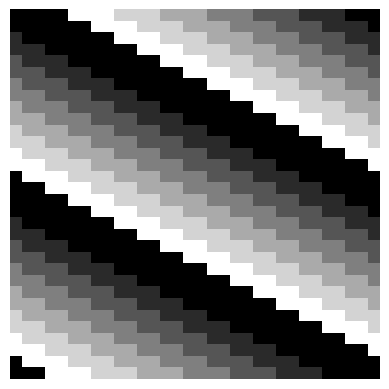

In [10]:
img1 = arnold(image,10)
plt.imshow(img1,cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

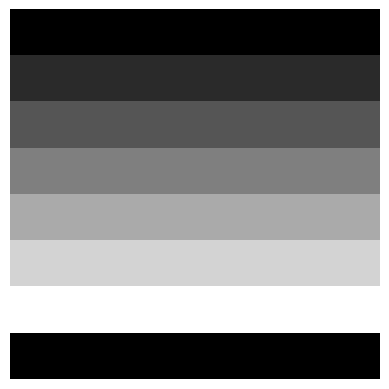

In [11]:
plt.imshow(undo_arnold(img1,10),cmap="gray")
plt.axis("off")

## Random Sequence Generation

In [12]:
import hashlib
import numpy as np
from math import sin,cos,floor,ceil,log

def generate_sequence_values(image,alpha=1,beta=1):
    height,width = image.shape
    n,m = ceil(log(height,2)), ceil(log(width,2))
    
    arr = np.asarray(image, dtype=np.uint8)
    arr = np.ascontiguousarray(arr)
    hash_value = hashlib.sha256(arr.tobytes()).hexdigest()

    h1 = int(hash_value[48:],16)/(2**14)
    h2 = int(hash_value[32:48],16)/(2**14)
    g1 = int(hash_value[16:32],16)/(2**14)
    g2 = int(hash_value[:16],16)/(2**14)
    t = np.sum(image)/(255*(2**(2*n)))

    x_0 = float((h1+t+1)%1)
    y_0 = float((h2+t+1)%1)
    z_0 = float((g1+g2+t+1)%1)

    seq=[(x_0,y_0,z_0)]
    loop = height*width
    for _ in range(loop-1):
        x_1 = cos(alpha*x_0)*sin(1/(y_0*((1-z_0)**2)))
        y_1 = cos(alpha*x_0*y_0+beta*z_0)
        z_1 = x_0
        seq.append((x_1,y_1,z_1))
        x_0,y_0,z_0 = x_1,y_1,z_1

    n = len(seq)
    output = []
    counter = 0
    idx = 0
    while len(output)!=n:
        output.append(seq[counter][idx])
        counter = (counter+5)%n
        idx = (idx+1)%3

    result = []
    for i in range(n):
        L = floor(output[i]*(10**14))%256
        result.append(f"{L:08b}")

    return result

In [13]:
f"{10:08b}"

'00001010'

## Classical NEQR

In [14]:
def classical_neqr(image):
    height,width = len(image),len(image[0])
    mapping = {}

    for i in range(height):
        for j in range(width):
            mapping[(i,j)] = f"{image[i][j]:08b}"

    return mapping

In [15]:
image.shape

(32, 32)

In [16]:
len(generate_sequence_values(image))

1024

## Quantum XOR Block

In [17]:
def quantum_xor_block(seq,mapping):
    height = int(len(mapping)**0.5)
    for idx, bitstring in enumerate(seq):
        row,col = idx //height, idx % height
        tgt = mapping[(row,col)]
        res = bin(int(bitstring, 2) ^ int(tgt, 2))[2:]
        mapping[(row,col)] = f"{int(res,2):08b}"

    return mapping

In [45]:
l=[int(i) for i in list("1001")]
s="".join([str(i) for i in l])
s

'1001'

## Contolled XOR Scrambling

In [18]:
def controlled_qubit_level_based_scrambling(seq,mapping):
    height = int(len(mapping)**0.5)
    for idx, bitstring in enumerate(seq):
        row,col = idx //height, idx % height
        tgt = [int(i) for i in list(mapping[(row,col)])]
        cs = int(bitstring,2)%5
        if cs%2 == 0:
            tgt[4],tgt[7]= tgt[7],tgt[4]
            tgt[3],tgt[6]= tgt[6],tgt[3]
            tgt[2],tgt[5]= tgt[5],tgt[2]
            tgt[4],tgt[1]= tgt[1],tgt[4]
            tgt[2],tgt[0]= tgt[0],tgt[2]
            tgt[4],tgt[5]= tgt[5],tgt[4]
            tgt[3],tgt[2]= tgt[2],tgt[3]
            tgt[1],tgt[0]= tgt[0],tgt[1]
        else:
            tgt[0] ^= tgt[7]
            tgt[1] ^= tgt[6]
            tgt[2] ^= tgt[5]
            tgt[3] ^= tgt[4]
            tgt[0] ^= tgt[5]
        
            tgt[7], tgt[2] = tgt[2], tgt[7]
            tgt[6], tgt[4] = tgt[4], tgt[6]
            tgt[5], tgt[1] = tgt[1], tgt[5]
            tgt[3], tgt[0] = tgt[0], tgt[3]
            tgt[1], tgt[0] = tgt[0], tgt[1]
            tgt[4], tgt[1] = tgt[1], tgt[4]

        mapping[(row,col)] = "".join([str(i) for i in tgt])

    return mapping

In [24]:
def undo_controlled_qubit_level_based_scrambling(seq, mapping):
    height = int(len(mapping) ** 0.5)

    for idx, bitstring in enumerate(seq):
        row, col = idx // height, idx % height
        tgt = [int(i) for i in list(mapping[(row, col)])]

        cs = int(bitstring, 2) % 5

        # Reverse operations in reverse order
        if cs % 2 == 0:
            # swap operations are self-inverse
            tgt[1], tgt[0] = tgt[0], tgt[1]
            tgt[3], tgt[2] = tgt[2], tgt[3]
            tgt[4], tgt[5] = tgt[5], tgt[4]
            tgt[2], tgt[0] = tgt[0], tgt[2]
            tgt[4], tgt[1] = tgt[1], tgt[4]
            tgt[2], tgt[5] = tgt[5], tgt[2]
            tgt[3], tgt[6] = tgt[6], tgt[3]
            tgt[4], tgt[7] = tgt[7], tgt[4]

        else:
            # reverse order of odd branch operations

            # swaps (self-inverse)
            tgt[4], tgt[1] = tgt[1], tgt[4]
            tgt[1], tgt[0] = tgt[0], tgt[1]
            tgt[3], tgt[0] = tgt[0], tgt[3]
            tgt[5], tgt[1] = tgt[1], tgt[5]
            tgt[6], tgt[4] = tgt[4], tgt[6]
            tgt[7], tgt[2] = tgt[2], tgt[7]

            # XORs (also self-inverse when repeated)
            tgt[0] ^= tgt[5]
            tgt[3] ^= tgt[4]
            tgt[2] ^= tgt[5]
            tgt[1] ^= tgt[6]
            tgt[0] ^= tgt[7]

        mapping[(row, col)] = "".join(str(i) for i in tgt)

    return mapping

In [19]:
def display_image(mapping):
    height = int(len(mapping)**0.5)
    output = np.zeros((height,height))

    for (i,j) in mapping:
        output[i][j]=int(mapping[(i,j)],2)

    return output

## Examples

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

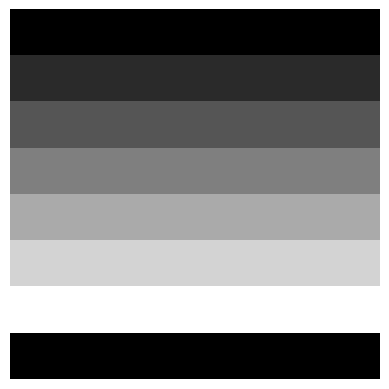

In [52]:
import numpy as np
import matplotlib.pyplot as plt

height, width = 32,32
bands = 7
band_height = height // bands

image = np.zeros((height, width), dtype=np.uint8)

for i in range(bands):
    intensity = int(255 * i / (bands - 1))
    image[i * band_height:(i + 1) * band_height, :] = intensity

plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

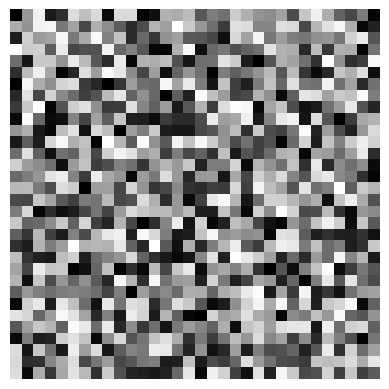

In [59]:
img = arnold(image,1)
mapping = classical_neqr(img)
seq= generate_sequence_values(image)
mapping = quantum_xor_block(seq,mapping)
mapping = controlled_qubit_level_based_scrambling(seq,mapping)
final = display_image(mapping)

plt.imshow(final, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

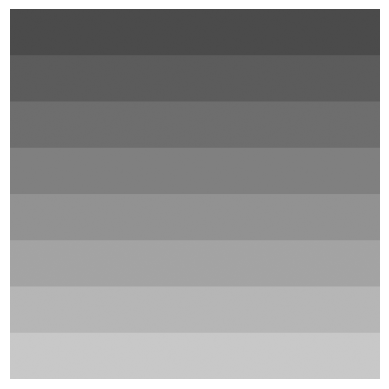

In [23]:
import numpy as np
import matplotlib.pyplot as plt

height, width = 512,512
bands = 8
band_height = height // bands

image = np.zeros((height, width), dtype=np.uint8)

min_val = 75
max_val = 200

for i in range(bands):
    intensity = int(min_val + (max_val - min_val) * i / (bands - 1))
    image[i * band_height:(i + 1) * band_height, :] = intensity

plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

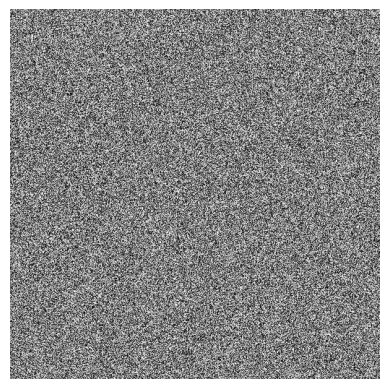

In [25]:
img = arnold(image,1)
mapping = classical_neqr(img)
seq= generate_sequence_values(image)
mapping = quantum_xor_block(seq,mapping)
mapping = controlled_qubit_level_based_scrambling(seq,mapping)
final = display_image(mapping)

plt.imshow(final, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

In [26]:
arn = arnold(image,1)
mapping = classical_neqr(arn)
seq= generate_sequence_values(image)

mapping = quantum_xor_block(seq,mapping)
xor_img = display_image(mapping)

mapping = controlled_qubit_level_based_scrambling(seq,mapping)
scr_img = display_image(mapping)

mapping = undo_controlled_qubit_level_based_scrambling(seq,mapping)
mapping = quantum_xor_block(seq,mapping)
arn_img = display_image(mapping)
original = undo_arnold(arn_img,1)

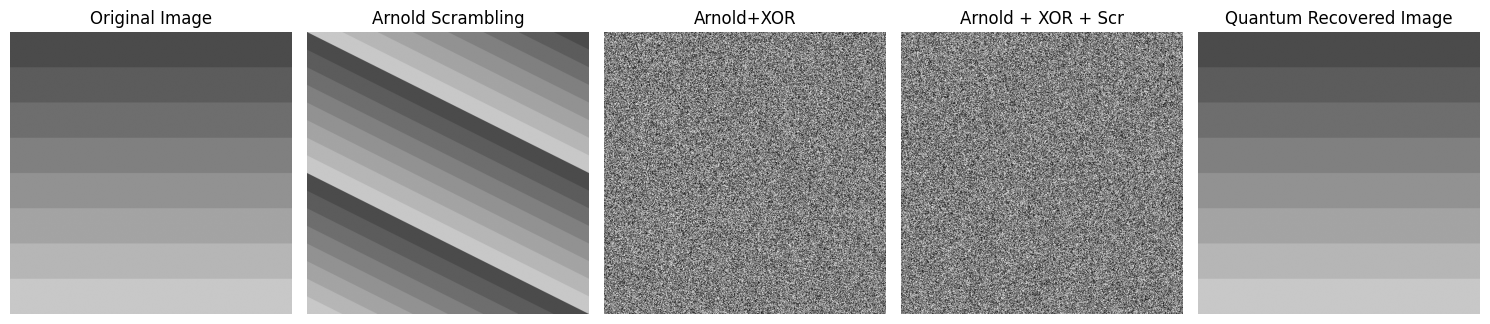

In [27]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(arn, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Arnold Scrambling")
axes[1].axis('off')

axes[2].imshow(xor_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Arnold+XOR")
axes[2].axis('off')

axes[3].imshow(scr_img, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Arnold + XOR + Scr")
axes[3].axis('off')

axes[4].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[4].set_title("Quantum Recovered Image")
axes[4].axis('off')

plt.tight_layout()
plt.show()

## Actual Images

In [29]:
from PIL import Image
lena = Image.open("/kaggle/input/datasets/bramjit/quantum-image-test/lena_gray.bmp")
lena = np.array(lena)

In [84]:
lena.shape

(512, 512)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

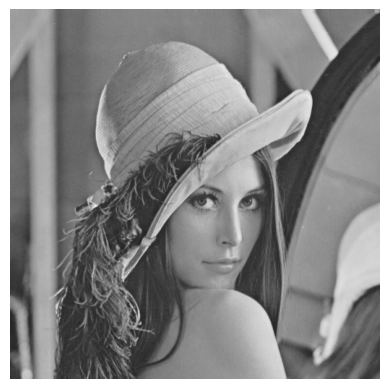

In [85]:
plt.imshow(lena, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

In [30]:
arn = arnold(lena,1)
mapping = classical_neqr(arn)
seq= generate_sequence_values(lena)

mapping = quantum_xor_block(seq,mapping)
xor_img = display_image(mapping)

mapping = controlled_qubit_level_based_scrambling(seq,mapping)
scr_img = display_image(mapping)

mapping = undo_controlled_qubit_level_based_scrambling(seq,mapping)
mapping = quantum_xor_block(seq,mapping)
arn_img = display_image(mapping)
original = undo_arnold(arn_img,1)

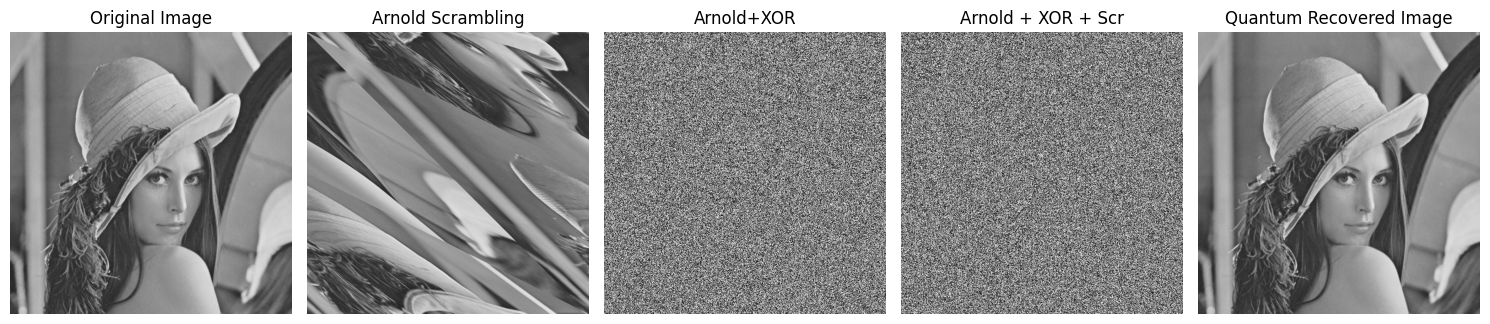

In [31]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(lena, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(arn, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Arnold Scrambling")
axes[1].axis('off')

axes[2].imshow(xor_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Arnold+XOR")
axes[2].axis('off')

axes[3].imshow(scr_img, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Arnold + XOR + Scr")
axes[3].axis('off')

axes[4].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[4].set_title("Quantum Recovered Image")
axes[4].axis('off')

plt.tight_layout()
plt.show()

In [32]:
from PIL import Image
barb = Image.open("/kaggle/input/datasets/bramjit/quantum-image-test/barbara_gray.bmp")
barb = np.array(barb)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

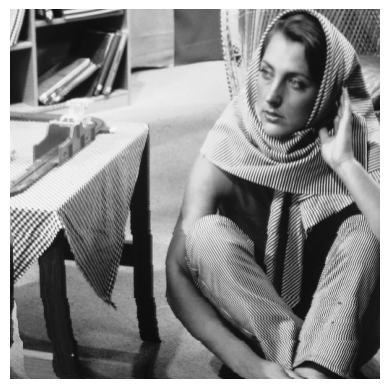

In [36]:
plt.imshow(barb, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

In [33]:
arn = arnold(barb,1)
mapping = classical_neqr(arn)
seq= generate_sequence_values(barb)

mapping = quantum_xor_block(seq,mapping)
xor_img = display_image(mapping)

mapping = controlled_qubit_level_based_scrambling(seq,mapping)
scr_img = display_image(mapping)

mapping = undo_controlled_qubit_level_based_scrambling(seq,mapping)
mapping = quantum_xor_block(seq,mapping)
arn_img = display_image(mapping)
original = undo_arnold(arn_img,1)

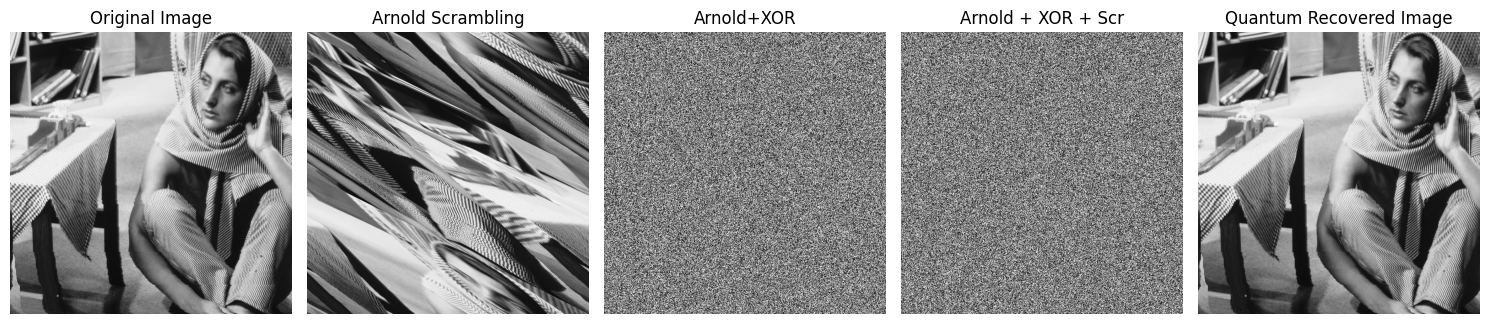

In [34]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(barb, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(arn, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Arnold Scrambling")
axes[1].axis('off')

axes[2].imshow(xor_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Arnold+XOR")
axes[2].axis('off')

axes[3].imshow(scr_img, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Arnold + XOR + Scr")
axes[3].axis('off')

axes[4].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[4].set_title("Quantum Recovered Image")
axes[4].axis('off')

plt.tight_layout()
plt.show()